In [72]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [73]:
# Set random seeds for reproducibility
torch.manual_seed(42)

In [74]:
df = pd.read_csv("/fmnist_small.csv")
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,9,0,0,0,0,0,0,0,0,0,...,0,7,0,50,205,196,213,165,0,0
1,7,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0,0,...,142,142,142,21,0,3,0,0,0,0
3,8,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,8,0,0,0,0,0,0,0,0,0,...,213,203,174,151,188,10,0,0,0,0


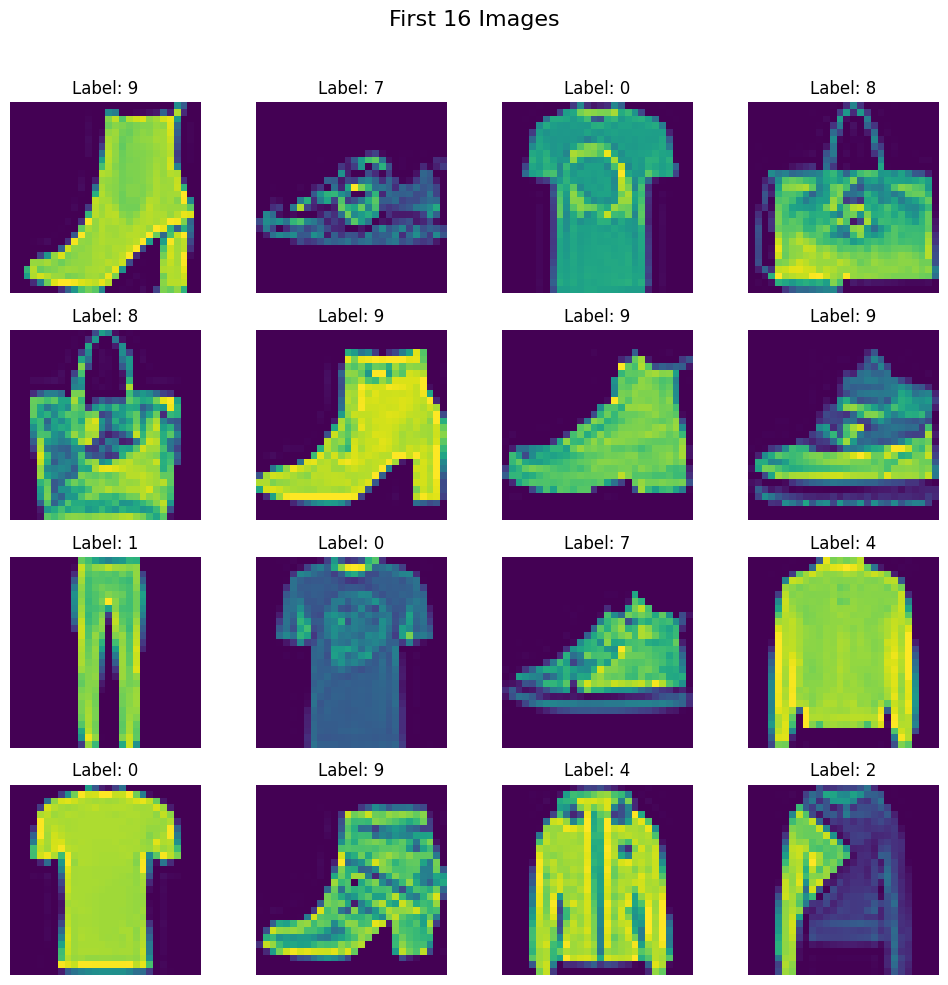

In [75]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()

In [76]:
X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [77]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [78]:
#Scaling the images
X_train = X_train/255.0
X_test = X_test/255.0

In [79]:
X_train

array([[0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       ...,
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.       , 0.       ,
        0.       ],
       [0.       , 0.       , 0.       , ..., 0.0627451, 0.       ,
        0.       ]])

In [80]:
# create CustomDataset Class
class CustomDataset(Dataset):

  def __init__(self, features, labels):

    self.features = torch.tensor(features, dtype=torch.float32)
    self.labels = torch.tensor(labels, dtype=torch.long)

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    return self.features[index], self.labels[index]

In [81]:
# create train_dataset object
train_dataset = CustomDataset(X_train, y_train)

In [87]:
train_dataset[0]

(tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
         0.0000, 0.0000, 0.0

In [82]:
# create test_dataset object
test_dataset = CustomDataset(X_test, y_test)

In [89]:
# create train and test loader
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [90]:
# define NN class

class MyNN(nn.Module):

  def __init__(self, num_features) :

    super().__init__()
    self.model = nn.Sequential(
        nn.Linear(num_features, 128),
        nn.ReLU(),
        nn.Linear(128, 64),
        nn.ReLU(),
        nn.Linear(64, 10)

    )

  def forward(self, x):

    return self.model(x)

In [91]:
# set learning rate and epochs
epochs = 100
learning_rate = 0.1

In [94]:
# instatiate the model
model = MyNN(X_train.shape[1])

#Loss function
criterion = nn.CrossEntropyLoss()

#Optimizer
optimizer = optim.SGD(model.parameters(), lr=learning_rate)

In [100]:
len(train_loader)                                                     # Total batches

150

In [101]:
# training loop
for epoch in range(epochs):
  total_epoch_loss = 0
  for batch_features, batch_labels in train_loader:

    #forward pass
    output = model(batch_features)

    #loss calculation
    loss = criterion(output, batch_labels)

    #backward pass
    optimizer.zero_grad()
    loss.backward()

    #update parameters
    optimizer.step()

    total_epoch_loss = total_epoch_loss + loss.item()

    #average loss per batch
    avg_loss = total_epoch_loss/len(train_dataset)
    print(f"Epoch: {epoch + 1} , Loss: {avg_loss}")

Streaming output truncated to the last 5000 lines.
Epoch: 67 , Loss: 9.023439941605223e-06
Epoch: 67 , Loss: 9.041214210204393e-06
Epoch: 67 , Loss: 9.219950522189417e-06
Epoch: 67 , Loss: 9.331672184392423e-06
Epoch: 67 , Loss: 9.464682631611747e-06
Epoch: 67 , Loss: 9.546986469407177e-06
Epoch: 67 , Loss: 9.651129663931594e-06
Epoch: 67 , Loss: 9.73416894339607e-06
Epoch: 67 , Loss: 9.81302129124136e-06
Epoch: 67 , Loss: 9.914480009077427e-06
Epoch: 67 , Loss: 9.988621362329772e-06
Epoch: 67 , Loss: 1.0035954546765425e-05
Epoch: 67 , Loss: 1.0065750569386485e-05
Epoch: 67 , Loss: 1.012619001509544e-05
Epoch: 67 , Loss: 1.0188287221050512e-05
Epoch: 67 , Loss: 1.0419569540924083e-05
Epoch: 67 , Loss: 1.0529332527463945e-05
Epoch: 67 , Loss: 1.0610309697464497e-05
Epoch: 67 , Loss: 1.0715985960511413e-05
Epoch: 67 , Loss: 1.0774364418466576e-05
Epoch: 67 , Loss: 1.1144216575000125e-05
Epoch: 67 , Loss: 1.1276574077783153e-05
Epoch: 67 , Loss: 1.1417704251167985e-05
Epoch: 67 , Loss: 1.

In [102]:
# set model to eval mode
model.eval()

MyNN(
  (model): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [103]:
# evaluation code
total = 0
correct = 0

with torch.no_grad():
  for batch_features, batch_labels in test_loader:
    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)
    total = total + batch_labels.shape[0]
    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.835
